# 04 - H4 + XGBoost
Mas mahabang timeframe, mas malakas na model

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
load_dotenv()
import MetaTrader5 as mt5

mt5.initialize()
login = int(os.getenv('MT5_LOGIN', '0'))
password = os.getenv('MT5_PASSWORD')
server = os.getenv('MT5_SERVER', '').strip()
mt5.login(login, password=password, server=server)

print('Ready')

Ready


## 1. Fetch H4 Data (2 years)

In [2]:
# Fetch H4 data — 2 years
symbol = 'EURUSD'
rates = mt5.copy_rates_from_pos(symbol, mt5.TIMEFRAME_H4, 0, 4500)
mt5.shutdown()

df = pd.DataFrame(rates)
df['time'] = pd.to_datetime(df['time'], unit='s')
df = df.set_index('time')

print(f'{symbol}: {len(df)} H4 bars loaded')
print(f'Range: {df.index[0]} to {df.index[-1]}')

EURUSD: 4500 H4 bars loaded
Range: 2023-07-07 00:00:00 to 2026-05-29 20:00:00


## 2. Feature Engineering (H4)

In [3]:
# Moving Averages
df['sma_10'] = df['close'].rolling(10).mean()
df['sma_20'] = df['close'].rolling(20).mean()
df['sma_50'] = df['close'].rolling(50).mean()
df['ema_12'] = df['close'].ewm(span=12, adjust=False).mean()
df['ema_26'] = df['close'].ewm(span=26, adjust=False).mean()

# Price vs MA
df['pct_from_sma20'] = (df['close'] - df['sma_20']) / df['sma_20'] * 100
df['pct_from_sma50'] = (df['close'] - df['sma_50']) / df['sma_50'] * 100

# RSI
delta = df['close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(span=14, adjust=False).mean()
avg_loss = loss.ewm(span=14, adjust=False).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df['rsi'] = 100 - (100 / (1 + rs))

# MACD
ema12 = df['close'].ewm(span=12, adjust=False).mean()
ema26 = df['close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema12 - ema26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

# Bollinger Bands
bb_mid = df['close'].rolling(20).mean()
bb_std = df['close'].rolling(20).std()
df['bb_upper'] = bb_mid + (2 * bb_std)
df['bb_lower'] = bb_mid - (2 * bb_std)
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / bb_mid * 100
df['bb_position'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

# ATR
high_low = df['high'] - df['low']
high_close = (df['high'] - df['close'].shift()).abs()
low_close = (df['low'] - df['close'].shift()).abs()
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['atr'] = tr.rolling(14).mean()
df['atr_pct'] = df['atr'] / df['close'] * 100

# Returns
df['return_1'] = df['close'].pct_change(1)
df['return_5'] = df['close'].pct_change(5)

# Candle
df['body'] = abs(df['close'] - df['open'])
df['upper_wick'] = df['high'] - df[['open', 'close']].max(axis=1)
df['lower_wick'] = df[['open', 'close']].min(axis=1) - df['low']
df['range'] = df['high'] - df['low']
df['range_pct'] = df['range'] / df['close'] * 100

# Volume
df['volume_ma'] = df['tick_volume'].rolling(20).mean()
df['volume_ratio'] = df['tick_volume'] / df['volume_ma'].replace(0, np.nan)

# Lag
df['close_lag1'] = df['close'].shift(1)
df['close_lag2'] = df['close'].shift(2)
df['rsi_lag1'] = df['rsi'].shift(1)

print(f'Features created: {len(df.columns)}')

Features created: 36


## 3. Target — H4 RR (40TP / 20SL, next 24 candles)

In [4]:
TP_PIPS = 0.0040  # 40 pips
SL_PIPS = 0.0020  # 20 pips (1:2 RR)
LOOKAHEAD = 24    # next 24 H4 candles = 4 days

targets = []
for i in range(len(df) - LOOKAHEAD):
    entry = df['close'].iloc[i]
    tp = entry + TP_PIPS
    sl = entry - SL_PIPS
    future_highs = df['high'].iloc[i+1:i+LOOKAHEAD+1]
    future_lows = df['low'].iloc[i+1:i+LOOKAHEAD+1]
    tp_hit = (future_highs >= tp).any()
    sl_hit = (future_lows <= sl).any()
    if tp_hit and not sl_hit:
        targets.append(1)
    elif sl_hit and not tp_hit:
        targets.append(0)
    else:
        targets.append(-1)

df = df.iloc[:len(targets)].copy()
df['Target'] = targets
df = df[df['Target'] != -1]

win = (df['Target'] == 1).sum()
loss = (df['Target'] == 0).sum()
print(f'Total: {len(df)}')
print(f'WIN: {win} | LOSS: {loss} | Ratio: {win/(win+loss)*100:.1f}%')

Total: 2406
WIN: 816 | LOSS: 1590 | Ratio: 33.9%


## 4. Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df.columns if c != 'Target']
ml_data = df[feature_cols + ['Target']].dropna()

X = ml_data[feature_cols]
y = ml_data['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f'X: {X.shape}')
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train BUY: {y_train.sum()}/{len(y_train)} ({y_train.mean()*100:.1f}%)')
print(f'Test  BUY: {y_test.sum()}/{len(y_test)} ({y_test.mean()*100:.1f}%)')

X: (2378, 36)
Train: 1902 | Test: 476
Train BUY: 654/1902 (34.4%)
Test  BUY: 144/476 (30.3%)


## 5. Train XGBoost

In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
print('XGBoost trained!')

XGBoost trained!


## 6. Evaluate

In [7]:
y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.2%}')
print()
print(classification_report(y_test, y_pred, target_names=['LOSS', 'WIN']))

Accuracy: 68.91%

              precision    recall  f1-score   support

        LOSS       0.79      0.75      0.77       332
         WIN       0.49      0.56      0.52       144

    accuracy                           0.69       476
   macro avg       0.64      0.65      0.64       476
weighted avg       0.70      0.69      0.69       476



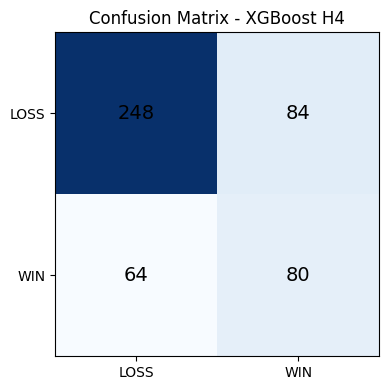

In [8]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['LOSS', 'WIN'])
ax.set_yticklabels(['LOSS', 'WIN'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)
ax.set_title('Confusion Matrix - XGBoost H4')
plt.tight_layout(); plt.show()

## 7. Feature Importance

In [9]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 10:')
importance.head(10)

Top 10:


,feature,importance
10,ema_12,0.113324
8,sma_20,0.054604
3,close,0.049349
19,bb_lower,0.043979
16,macd_signal,0.041199
18,bb_upper,0.039695
9,sma_50,0.039387
5,spread,0.035667
31,volume_ma,0.034187
11,ema_26,0.033881


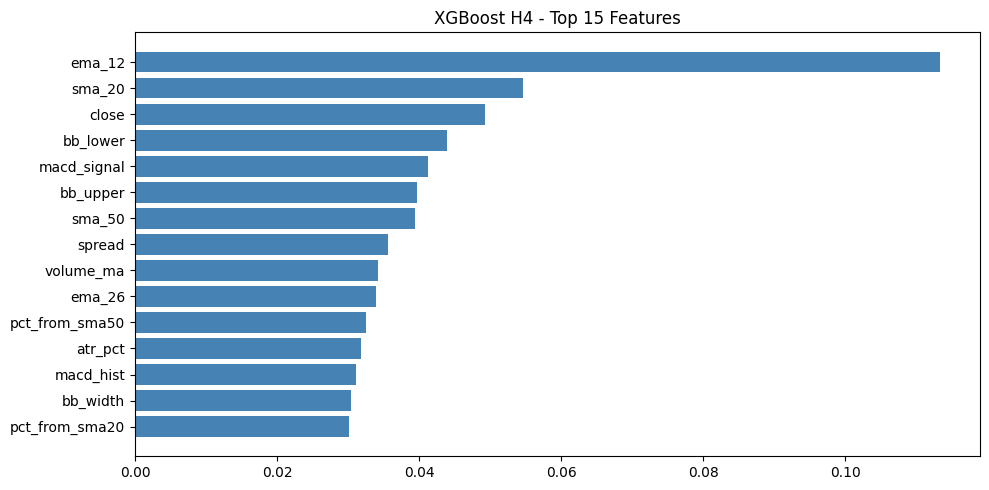

In [10]:
top = importance.head(15)
plt.figure(figsize=(10, 5))
plt.barh(range(len(top)), top['importance'], color='steelblue')
plt.yticks(range(len(top)), top['feature'])
plt.gca().invert_yaxis()
plt.title('XGBoost H4 - Top 15 Features')
plt.tight_layout(); plt.show()